# 3단계: GapFilling 레시피 추천 모델 구현

## 목표
- 장바구니 재료 기반 레시피 매칭 알고리즘 구현
- 부족한 재료(Gap) 식별 및 추천 로직 구현
- 인기도 기반 점수 산정
- 모델 학습 및 최적화

In [64]:
# 필수 라이브러리 임포트
import pandas as pd
import numpy as np
import pickle
import json
from collections import defaultdict, Counter
from typing import List, Dict, Set, Tuple, Optional
import matplotlib.pyplot as plt
import warnings

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

warnings.filterwarnings('ignore')

print("라이브러리 로딩 완료")

라이브러리 로딩 완료


## 3.1 데이터 로딩

In [65]:
# 2단계에서 저장한 데이터 로딩
PROCESSED_DIR = '../data/processed'

# 레시피 데이터
df_recipes = pd.read_csv(f'{PROCESSED_DIR}/recipes_analyzed.csv', encoding='utf-8-sig')
print(f"레시피 데이터: {len(df_recipes):,}개")

# 레시피-재료 관계 데이터
df_recipe_ingredients = pd.read_csv(f'{PROCESSED_DIR}/recipe_ingredients.csv', encoding='utf-8-sig')
print(f"레시피-재료 관계: {len(df_recipe_ingredients):,}개")

# 역인덱스 (재료 -> 레시피 목록)
with open(f'{PROCESSED_DIR}/ingredient_to_recipes.pkl', 'rb') as f:
    ingredient_to_recipes = pickle.load(f)
print(f"역인덱스: {len(ingredient_to_recipes):,}개 재료")

# 재료 사전
with open(f'{PROCESSED_DIR}/ingredient_dict.json', 'r', encoding='utf-8') as f:
    ingredient_dict = json.load(f)
print(f"재료 사전: {len(ingredient_dict):,}개")

# 동의어 사전
with open(f'{PROCESSED_DIR}/synonym_dict.json', 'r', encoding='utf-8') as f:
    synonym_dict = json.load(f)
print(f"동의어 사전: {len(synonym_dict):,}개 표준형")

레시피 데이터: 23,192개
레시피-재료 관계: 198,361개
역인덱스: 9,147개 재료
재료 사전: 1,415개
동의어 사전: 23개 표준형


## 3.2 레시피 데이터 구조화

In [66]:
# 레시피별 재료 세트 구축
recipe_ingredient_sets = {}

for recipe_id, group in df_recipe_ingredients.groupby('recipe_id'):
    ingredients = set(group['ingredient_normalized'].dropna().unique())
    recipe_ingredient_sets[recipe_id] = ingredients

print(f"레시피별 재료 세트: {len(recipe_ingredient_sets):,}개")

# 샘플 확인
sample_recipe_id = list(recipe_ingredient_sets.keys())[0]
print(f"\n샘플 레시피 (ID: {sample_recipe_id}):")
print(f"재료: {recipe_ingredient_sets[sample_recipe_id]}")

레시피별 재료 세트: 23,191개

샘플 레시피 (ID: 7016813):
재료: {'소금', '소고기', '대파', '참기름', '간장', '마늘', '떡국떡', '계란', '멸치육수', '김가루'}


In [67]:
# 레시피 메타데이터 딕셔너리 구축
# ★ 변경: title 대신 CKG_NM(요리명) 우선 사용
recipe_metadata = {}

for _, row in df_recipes.iterrows():
    recipe_id = row.get('RCP_SNO')
    if recipe_id is None:
        continue
    
    # CKG_NM (요리명)을 우선 사용, 없으면 RCP_TTL 사용
    dish_name = row.get('CKG_NM', '') or ''
    recipe_title = row.get('RCP_TTL', '') or ''
    
    recipe_metadata[recipe_id] = {
        'name': dish_name,                 # ★ 정식 요리 명칭 (예: 소고기떡국)
        'title': recipe_title,              # 레시피 제목 (예: 멸치육수 소고기 떡국 만드는법)
        'view_count': row.get('INQ_CNT', 0) or 0,
        'recommend_count': row.get('RCMM_CNT', 0) or 0,
        'scrap_count': row.get('SRAP_CNT', 0) or 0,
        'category': row.get('CKG_KND_ACTO_NM', ''),
        'difficulty': row.get('CKG_DODF_NM', ''),
        'cooking_time': row.get('CKG_TIME_NM', ''),
        'popularity_score': row.get('popularity_score', 0) or 0,
        'ingredient_count': row.get('ingredient_count', 0) or 0
    }

print(f"레시피 메타데이터: {len(recipe_metadata):,}개")

# 샘플 확인 (요리명 vs 제목 비교)
sample_ids = list(recipe_metadata.keys())[:3]
print("\n샘플 레시피 (요리명 vs 제목 비교):")
for sid in sample_ids:
    meta = recipe_metadata[sid]
    print(f"  - 요리명: {meta['name']} | 제목: {meta['title'][:30]}...")

레시피 메타데이터: 23,192개

샘플 레시피 (요리명 vs 제목 비교):
  - 요리명: 소고기떡국 | 제목: 멸치육수 소고기 떡국 만드는법...
  - 요리명: 된장수육 | 제목: #수육용삼겹살 #된장수육만들기 #일상먹거리 #무생채와함...
  - 요리명: 우거지감자탕 | 제목: 우거지감자탕 뼈해장국 끓이는법...


## 3.3 GapFilling 모델 클래스 구현

In [68]:
class RecipeGapFillingModel:
    """
    장바구니 기반 레시피 추천 및 GapFilling 모델 v2.0
    
    장바구니에 담긴 재료를 분석하여:
    1. 만들 수 있는 레시피를 추천 (요리명 CKG_NM 사용)
    2. 부족한 재료(Gap)를 식별하여 추가 상품 추천
    3. 메인 재료 우선 추천 (육류/해산물 > 양념)
    4. 당연한 재료(물, 소금 등)는 추천에서 제외
    5. 재료→상품 매핑 (참치액→참치캔)
    
    필터링 규칙:
    - 최소 재료 3개 이상인 레시피만 추천
    - 보관법, 손질법 등 비요리 콘텐츠 제외
    - 인기도(조회수) 기준 필터링
    """
    
    VERSION = '2.0.0'
    
    # =====================================================
    # 1. 제외할 키워드 (비요리 콘텐츠)
    # =====================================================
    EXCLUDE_KEYWORDS = [
        '보관법', '보관방법', '보관하는', '손질법', '손질방법', '다듬기',
        '세척법', '씻는법', '해동', '냉동보관', '냉장보관',
        '고르는법', '고르는방법', '선별법',
        '효능', '효과', '칼로리', '만들기 전', '준비하기'
    ]
    
    # =====================================================
    # 2. 추천에서 제외할 재료 (당연히 있거나 구매할 필요 없는 것들)
    # =====================================================
    EXCLUDE_INGREDIENTS = {
        # 기본 조리 재료 (누구나 있음)
        '물', '냉수', '찬물', '뜨거운물', '끓는물', '미지근한물',
        '소금', '설탕', '후추', '후춧가루', '흑후추',
        '식용유', '기름', '포도씨유', '카놀라유',
        
        # 양념 기본 (대부분 가정에 있음)
        '간장', '진간장', '국간장', '양조간장',
        '고춧가루', '고추장', '된장',
        '참기름', '들기름',
        '식초', '맛술', '청주', '미림',
        '다진마늘', '다진파', '생강가루',
        
        # 추천 불가 재료 (실제 상품 없음)
        '얼음', '육수', '멸치육수', '다시마육수', '채수',
        '밥', '찬밥', '따뜻한밥',
    }
    
    # =====================================================
    # 3. 메인 재료 카테고리 (높은 가중치)
    # =====================================================
    MAIN_INGREDIENT_CATEGORIES = {
        # 육류 (가장 높은 가중치)
        '육류': [
            '소고기', '돼지고기', '닭고기', '오리고기', '양고기', '말고기',
            '삼겹살', '목살', '안심', '등심', '갈비', '차돌박이',
            '닭가슴살', '닭다리', '닭날개', '통닭',
            '소갈비', '소불고기', '돼지갈비', '제육',
            '베이컨', '햄', '소시지', '살라미',
            '불고기', '갈비살', '항정살', '가브리살', '우삼겹',
        ],
        # 해산물 (높은 가중치)
        '해산물': [
            '생선', '연어', '고등어', '갈치', '조기', '광어', '우럭', '참치',
            '오징어', '문어', '낙지', '주꾸미',
            '새우', '게', '꽃게', '대게', '랍스터',
            '조개', '바지락', '모시조개', '홍합', '전복', '굴', '가리비',
            '멸치', '북어', '황태', '대구', '명태',
            '참치캔', '고등어통조림', '연어통조림',
        ],
        # 주요 채소 (중간 가중치)
        '주요채소': [
            '배추', '무', '감자', '고구마', '당근', '양배추',
            '시금치', '깻잎', '상추', '청경채', '브로콜리',
            '호박', '애호박', '단호박', '가지', '오이',
            '버섯', '표고버섯', '양송이버섯', '느타리버섯', '팽이버섯',
            '두부', '콩나물', '숙주',
        ],
        # 탄수화물 주재료 (중간 가중치)
        '탄수화물': [
            '쌀', '현미', '잡곡',
            '면', '국수', '소면', '우동면', '라면사리', '당면', '쫄면',
            '스파게티면', '파스타면', '펜네', '마카로니',
            '떡', '떡국떡', '가래떡', '떡볶이떡',
            '빵', '식빵', '바게트',
        ],
    }
    
    # =====================================================
    # 4. 재료 → 상품 매핑 (실제 구매 가능한 상품으로 변환)
    # =====================================================
    INGREDIENT_TO_PRODUCT_MAP = {
        # 액젓류 → 원재료
        '참치액': '참치캔',
        '멸치액젓': '멸치',
        '까나리액젓': '멸치',
        '새우젓': '새우',
        
        # 육수류 → 원재료
        '멸치육수': '멸치',
        '다시마육수': '다시마',
        '채수': '양파',
        '사골육수': '사골',
        '치킨스톡': '닭고기',
        '비프스톡': '소고기',
        
        # 가공식품 → 원재료 또는 대체품
        '계란물': '계란',
        '달걀물': '계란',
        '전분물': '전분',
        '녹말물': '전분',
        
        # 분말류 → 원재료
        '마늘가루': '마늘',
        '양파가루': '양파',
        '생강가루': '생강',
        
        # 기타 매핑
        '통조림옥수수': '옥수수',
        '냉동새우': '새우',
        '냉동오징어': '오징어',
        '다진돼지고기': '돼지고기',
        '다진소고기': '소고기',
    }
    
    def __init__(self,
                 recipe_ingredient_sets: Dict[int, Set[str]],
                 ingredient_to_recipes: Dict[str, List[int]],
                 recipe_metadata: Dict[int, dict],
                 synonym_dict: Dict[str, List[str]]):
        """
        모델 초기화
        """
        self.recipe_ingredient_sets = recipe_ingredient_sets
        self.ingredient_to_recipes = ingredient_to_recipes
        self.recipe_metadata = recipe_metadata
        self.synonym_dict = synonym_dict
        
        # 역방향 동의어 매핑
        self.synonym_to_standard = {}
        for standard, synonyms in synonym_dict.items():
            for syn in synonyms:
                self.synonym_to_standard[syn] = standard
        
        # 메인 재료 집합 구축 (빠른 조회용)
        self.main_ingredients = set()
        for category_items in self.MAIN_INGREDIENT_CATEGORIES.values():
            self.main_ingredients.update(category_items)
        
        # 모델 파라미터 (v2.0 업데이트)
        self.params = {
            'min_match_ratio': 0.3,           # 최소 재료 매칭 비율
            'max_gap_count': 5,               # 최대 부족 재료 수
            'popularity_weight': 0.4,         # ★ 인기도 가중치 증가 (0.3→0.4)
            'match_weight': 0.4,              # 매칭 비율 가중치 (0.5→0.4)
            'gap_penalty_weight': 0.2,        # Gap 패널티 가중치
            'main_ingredient_bonus': 0.3,     # ★ 메인 재료 보너스
            'min_ingredients': 3,             # 최소 재료 개수
            'min_view_count': 500,            # ★ 최소 조회수 증가 (100→500)
        }
        
        # 유효한 레시피 필터링 (사전 계산)
        self.valid_recipe_ids = self._filter_valid_recipes()
        
        # 최대 인기도 캐싱
        self._max_popularity = max(
            (m.get('popularity_score', 0) or 0 for m in recipe_metadata.values()),
            default=1
        )
        
        print(f"GapFilling 모델 v{self.VERSION} 초기화 완료")
        print(f"  - 전체 레시피 수: {len(recipe_ingredient_sets):,}")
        print(f"  - 유효 레시피 수: {len(self.valid_recipe_ids):,}")
        print(f"  - 재료 수: {len(ingredient_to_recipes):,}")
        print(f"  - 메인 재료 수: {len(self.main_ingredients):,}")
        print(f"  - 제외 재료 수: {len(self.EXCLUDE_INGREDIENTS):,}")
    
    def _filter_valid_recipes(self) -> Set[int]:
        """유효한 레시피만 필터링"""
        valid_ids = set()
        excluded_count = {'keyword': 0, 'ingredients': 0, 'view_count': 0}
        
        for recipe_id, ingredients in self.recipe_ingredient_sets.items():
            metadata = self.recipe_metadata.get(recipe_id, {})
            title = metadata.get('title', '') or metadata.get('name', '')
            view_count = metadata.get('view_count', 0) or 0
            
            if len(ingredients) < self.params['min_ingredients']:
                excluded_count['ingredients'] += 1
                continue
            
            is_excluded = False
            for keyword in self.EXCLUDE_KEYWORDS:
                if keyword in title:
                    is_excluded = True
                    excluded_count['keyword'] += 1
                    break
            if is_excluded:
                continue
            
            if view_count < self.params['min_view_count']:
                excluded_count['view_count'] += 1
                continue
            
            valid_ids.add(recipe_id)
        
        print(f"  필터링 제외: 재료부족 {excluded_count['ingredients']:,}개, "
              f"비요리 {excluded_count['keyword']:,}개, "
              f"저조회 {excluded_count['view_count']:,}개")
        
        return valid_ids
    
    def normalize_ingredient(self, name: str) -> str:
        """재료명 정규화"""
        if not name:
            return name
        name = str(name).strip()
        if name in self.synonym_to_standard:
            return self.synonym_to_standard[name]
        for standard in self.synonym_dict.keys():
            if standard in name:
                return standard
        return name
    
    def map_to_product(self, ingredient: str) -> str:
        """
        재료명을 실제 구매 가능한 상품명으로 매핑
        예: 참치액 → 참치캔, 멸치육수 → 멸치
        """
        if ingredient in self.INGREDIENT_TO_PRODUCT_MAP:
            return self.INGREDIENT_TO_PRODUCT_MAP[ingredient]
        return ingredient
    
    def is_main_ingredient(self, ingredient: str) -> bool:
        """메인 재료인지 확인 (육류, 해산물, 주요 채소)"""
        return ingredient in self.main_ingredients
    
    def should_exclude_from_gap(self, ingredient: str) -> bool:
        """Gap 추천에서 제외해야 하는 재료인지 확인"""
        return ingredient in self.EXCLUDE_INGREDIENTS
    
    def get_ingredient_weight(self, ingredient: str) -> float:
        """
        재료별 가중치 반환
        메인 재료: 1.5, 일반 재료: 1.0, 양념류: 0.5
        """
        if self.should_exclude_from_gap(ingredient):
            return 0.0  # 제외 재료는 가중치 0
        
        if self.is_main_ingredient(ingredient):
            return 1.5  # 메인 재료 가중치 증가
        
        # 양념류 판단 (EXCLUDE_INGREDIENTS에 없지만 양념인 경우)
        seasoning_keywords = ['가루', '소스', '장', '젓', '액', '분', '즙']
        if any(kw in ingredient for kw in seasoning_keywords):
            return 0.7
        
        return 1.0  # 일반 재료
    
    def find_candidate_recipes(self, cart_ingredients: List[str]) -> Set[int]:
        """후보 레시피 검색 (유효한 레시피만)"""
        candidates = set()
        for ingredient in cart_ingredients:
            normalized = self.normalize_ingredient(ingredient)
            if normalized in self.ingredient_to_recipes:
                for recipe_id in self.ingredient_to_recipes[normalized]:
                    if recipe_id in self.valid_recipe_ids:
                        candidates.add(recipe_id)
        return candidates
    
    def calculate_match_score(self, cart_set: Set[str], recipe_id: int) -> Dict:
        """매칭 점수 계산 (메인 재료 가중치 적용)"""
        recipe_ingredients = self.recipe_ingredient_sets.get(recipe_id, set())
        if not recipe_ingredients:
            return None
        
        matched = cart_set & recipe_ingredients
        gaps = recipe_ingredients - cart_set
        
        # 제외 재료를 Gap에서 제거
        filtered_gaps = [g for g in gaps if not self.should_exclude_from_gap(g)]
        
        # Gap을 상품명으로 매핑
        mapped_gaps = [self.map_to_product(g) for g in filtered_gaps]
        # 중복 제거 (참치액, 멸치육수 → 멸치 하나로)
        mapped_gaps = list(dict.fromkeys(mapped_gaps))
        
        match_ratio = len(matched) / len(recipe_ingredients) if recipe_ingredients else 0
        
        # 메인 재료 매칭 보너스 계산
        main_matched = sum(1 for m in matched if self.is_main_ingredient(m))
        main_bonus = main_matched * self.params['main_ingredient_bonus'] / max(len(recipe_ingredients), 1)
        
        # Gap의 가중치 합계 (메인 재료 Gap은 더 중요)
        gap_weighted_count = sum(self.get_ingredient_weight(g) for g in filtered_gaps)
        
        metadata = self.recipe_metadata.get(recipe_id, {})
        
        return {
            'recipe_id': recipe_id,
            'name': metadata.get('name', ''),              # ★ 요리명 (CKG_NM)
            'title': metadata.get('title', ''),            # 레시피 제목
            'matched_ingredients': list(matched),
            'gap_ingredients': mapped_gaps,                 # ★ 상품 매핑된 Gap
            'gap_ingredients_raw': list(filtered_gaps),    # 원본 Gap
            'match_ratio': match_ratio,
            'main_bonus': main_bonus,
            'matched_count': len(matched),
            'gap_count': len(mapped_gaps),
            'gap_weighted_count': gap_weighted_count,
            'total_ingredients': len(recipe_ingredients),
            'popularity_score': metadata.get('popularity_score', 0) or 0,
            'view_count': metadata.get('view_count', 0) or 0,
            'category': metadata.get('category', ''),
            'difficulty': metadata.get('difficulty', '')
        }
    
    def calculate_final_score(self, match_info: Dict) -> float:
        """
        최종 점수 계산 (v2.0 알고리즘)
        
        Score = (match_weight * match_ratio)
              + (popularity_weight * norm_popularity)
              + (main_ingredient_bonus * main_bonus)
              - (gap_penalty_weight * gap_penalty)
        """
        match_ratio = match_info['match_ratio']
        main_bonus = match_info['main_bonus']
        gap_weighted_count = match_info['gap_weighted_count']
        popularity = match_info['popularity_score']
        
        norm_popularity = popularity / self._max_popularity if self._max_popularity > 0 else 0
        
        # Gap 패널티 (가중치 적용된 Gap 수 기준)
        gap_penalty = min(gap_weighted_count / (self.params['max_gap_count'] * 1.5), 1.0)
        
        score = (
            self.params['match_weight'] * match_ratio +
            self.params['popularity_weight'] * norm_popularity +
            main_bonus -
            self.params['gap_penalty_weight'] * gap_penalty
        )
        
        return max(0, min(1, score))
    
    def recommend(self,
                  cart_ingredients: List[str],
                  top_k: int = 10,
                  min_match_ratio: float = None,
                  max_gap_count: int = None) -> List[Dict]:
        """
        장바구니 기반 레시피 추천 (v2.0)
        
        반환 형식:
        - name: 요리명 (CKG_NM) - 예: "소고기무국"
        - gap_ingredients: 상품 매핑된 Gap - 예: ["대파", "참치캔"]
        """
        if min_match_ratio is None:
            min_match_ratio = self.params['min_match_ratio']
        if max_gap_count is None:
            max_gap_count = self.params['max_gap_count']
        
        cart_set = set(self.normalize_ingredient(ing) for ing in cart_ingredients)
        candidates = self.find_candidate_recipes(cart_ingredients)
        
        if not candidates:
            return []
        
        results = []
        for recipe_id in candidates:
            match_info = self.calculate_match_score(cart_set, recipe_id)
            if match_info is None:
                continue
            
            if match_info['match_ratio'] < min_match_ratio:
                continue
            if match_info['gap_count'] > max_gap_count:
                continue
            
            match_info['final_score'] = self.calculate_final_score(match_info)
            results.append(match_info)
        
        results.sort(key=lambda x: x['final_score'], reverse=True)
        return results[:top_k]
    
    def get_gap_recommendations(self,
                                 cart_ingredients: List[str],
                                 top_k_recipes: int = 5,
                                 top_k_gaps: int = 10) -> Dict:
        """
        Gap 기반 추가 재료 추천 (v2.0)
        메인 재료를 우선 추천
        """
        recommendations = self.recommend(cart_ingredients, top_k=top_k_recipes)
        
        if not recommendations:
            return {'gap_ingredients': [], 'recipes': [], 'message': '매칭되는 레시피가 없습니다.'}
        
        # Gap 재료 빈도 및 가중치 집계
        gap_scores = defaultdict(lambda: {'frequency': 0, 'weight': 0, 'recipes': []})
        
        for rec in recommendations:
            for gap in rec['gap_ingredients']:
                weight = self.get_ingredient_weight(gap)
                gap_scores[gap]['frequency'] += 1
                gap_scores[gap]['weight'] += weight * rec['final_score']  # 레시피 점수 반영
                gap_scores[gap]['recipes'].append({
                    'recipe_id': rec['recipe_id'],
                    'name': rec['name'],                 # ★ 요리명 사용
                    'match_ratio': rec['match_ratio']
                })
        
        # 가중치 점수로 정렬 (메인 재료가 더 높은 점수)
        sorted_gaps = sorted(
            gap_scores.items(),
            key=lambda x: x[1]['weight'],
            reverse=True
        )[:top_k_gaps]
        
        gap_recommendations = []
        for gap_name, gap_info in sorted_gaps:
            gap_recommendations.append({
                'ingredient': gap_name,
                'is_main_ingredient': self.is_main_ingredient(gap_name),
                'frequency': gap_info['frequency'],
                'score': round(gap_info['weight'], 3),
                'related_recipes': gap_info['recipes'][:3]
            })
        
        return {
            'gap_ingredients': gap_recommendations,
            'recipes': recommendations,
            'total_recipes_analyzed': len(recommendations)
        }

print("RecipeGapFillingModel v2.0 클래스 정의 완료")
print("  - CKG_NM (요리명) 사용")
print("  - 메인 재료 우선 추천")
print("  - 제외 재료 필터링")
print("  - 재료→상품 매핑")

RecipeGapFillingModel v2.0 클래스 정의 완료
  - CKG_NM (요리명) 사용
  - 메인 재료 우선 추천
  - 제외 재료 필터링
  - 재료→상품 매핑


## 3.4 모델 인스턴스 생성 및 테스트

In [69]:
# 모델 인스턴스 생성
model = RecipeGapFillingModel(
    recipe_ingredient_sets=recipe_ingredient_sets,
    ingredient_to_recipes=ingredient_to_recipes,
    recipe_metadata=recipe_metadata,
    synonym_dict=synonym_dict
)

  필터링 제외: 재료부족 678개, 비요리 325개, 저조회 13,014개
GapFilling 모델 v2.0.0 초기화 완료
  - 전체 레시피 수: 23,191
  - 유효 레시피 수: 9,174
  - 재료 수: 9,147
  - 메인 재료 수: 106
  - 제외 재료 수: 39


In [70]:
# 테스트 케이스 1: 소고기무국 재료 (이전 사용자 예시)
test_cart_1 = ['참치액', '간장', '참기름', '무', '물', '소고기']

print("=" * 80)
print(f"테스트 1: 장바구니 = {test_cart_1}")
print("=" * 80)

results_1 = model.recommend(test_cart_1, top_k=5)

for i, rec in enumerate(results_1, 1):
    print(f"\n[{i}] 요리명: {rec['name']}")
    print(f"    제목: {rec['title'][:40]}..." if len(rec['title']) > 40 else f"    제목: {rec['title']}")
    print(f"    매칭 비율: {rec['match_ratio']*100:.1f}%")
    print(f"    조회수: {rec['view_count']:,}")
    print(f"    보유 재료: {rec['matched_ingredients']}")
    print(f"    추천 재료 (Gap): {rec['gap_ingredients']}")  # 상품 매핑됨
    print(f"    최종 점수: {rec['final_score']:.3f}")

테스트 1: 장바구니 = ['참치액', '간장', '참기름', '무', '물', '소고기']

[1] 요리명: 소고기미역국
    제목: 소고기 미역국 맛있게 끓이는 방법
    매칭 비율: 57.1%
    조회수: 1,224
    보유 재료: ['소고기', '참기름', '참치액', '간장']
    추천 재료 (Gap): ['미역', '마늘']
    최종 점수: 0.448

[2] 요리명: 소고기무국
    제목: 탕국 끓이는법 소고기무국 레시피
    매칭 비율: 75.0%
    조회수: 1,401
    보유 재료: ['무', '소고기', '간장']
    추천 재료 (Gap): ['두부']
    최종 점수: 0.419

[3] 요리명: 소고기미역국
    제목: 소고기 미역국 끓이는 방법 자취생 미역국 끓이기 레시피
    매칭 비율: 80.0%
    조회수: 1,504
    보유 재료: ['소고기', '참기름', '간장', '물']
    추천 재료 (Gap): ['자른 미역']
    최종 점수: 0.363

[4] 요리명: 소고기장조림
    제목: 소고기장조림 만들기 본죽 스타일 소고기 장조림 레시피 소고기 장조림 부위
    매칭 비율: 66.7%
    조회수: 2,427
    보유 재료: ['소고기', '간장']
    추천 재료 (Gap): ['올리고당']
    최종 점수: 0.356

[5] 요리명: 물냉면
    제목: 맛있는 물냉면육수 만들기(feat. 청수 냉면)
    매칭 비율: 60.0%
    조회수: 1,437
    보유 재료: ['무', '소고기', '물']
    추천 재료 (Gap): ['계란', '청수 냉면']
    최종 점수: 0.316


In [71]:
# 테스트 케이스 2: Gap 추천 (메인 재료 우선 확인)
test_cart_2 = ['양파', '마늘', '간장', '후추']

print("=" * 80)
print(f"테스트 2: Gap 추천 - 장바구니 = {test_cart_2}")
print("=" * 80)

gap_results = model.get_gap_recommendations(test_cart_2, top_k_recipes=10, top_k_gaps=8)

print(f"\n분석된 레시피 수: {gap_results['total_recipes_analyzed']}개")
print(f"\n★ 추천 추가 재료 (메인 재료 우선):")

for i, gap in enumerate(gap_results['gap_ingredients'], 1):
    main_tag = "메인" if gap['is_main_ingredient'] else "일반"
    print(f"  {i}. [{main_tag}] {gap['ingredient']} (점수: {gap['score']:.3f}, 빈도: {gap['frequency']})")
    for recipe in gap['related_recipes'][:2]:
        print(f"      → {recipe['name']} (매칭 {recipe['match_ratio']*100:.0f}%)")

테스트 2: Gap 추천 - 장바구니 = ['양파', '마늘', '간장', '후추']

분석된 레시피 수: 10개

★ 추천 추가 재료 (메인 재료 우선):
  1. [일반] 고추 (점수: 0.789, 빈도: 3)
      → 양파장아찌 (매칭 40%)
      → 닭볶음탕 (매칭 60%)
  2. [일반] 대파 (점수: 0.789, 빈도: 4)
      → 참치두부조림 (매칭 30%)
      → 통마늘라면 (매칭 33%)
  3. [일반] 소주 (점수: 0.388, 빈도: 2)
      → 마늘장아찌 (매칭 40%)
      → 간장마늘쫑장아찌 (매칭 40%)
  4. [메인] 두부 (점수: 0.317, 빈도: 1)
      → 참치두부조림 (매칭 30%)
  5. [메인] 참치캔 (점수: 0.317, 빈도: 1)
      → 참치두부조림 (매칭 30%)
  6. [메인] 양배추 (점수: 0.313, 빈도: 1)
      → 양배추볶음 (매칭 60%)
  7. [메인] 닭고기 (점수: 0.287, 빈도: 1)
      → 닭볶음탕 (매칭 60%)
  8. [메인] 갈치 (점수: 0.283, 빈도: 1)
      → 갈치무조림 (매칭 31%)


In [72]:
# 테스트 케이스 3: 떡국 재료 (요리명 vs 제목 비교)
test_cart_3 = ['떡국떡', '계란', '대파', '소고기']

print("=" * 80)
print(f"테스트 3: 장바구니 = {test_cart_3}")
print("=" * 80)

results_3 = model.recommend(test_cart_3, top_k=5, min_match_ratio=0.3)

print("\n★ 요리명(CKG_NM) vs 제목(RCP_TTL) 비교:")
for i, rec in enumerate(results_3, 1):
    print(f"\n[{i}] 요리명: {rec['name']}")
    print(f"    제목: {rec['title'][:50]}...")
    print(f"    매칭: {rec['matched_count']}/{rec['total_ingredients']} ({rec['match_ratio']*100:.1f}%)")
    print(f"    조회수: {rec['view_count']:,}")
    print(f"    Gap: {rec['gap_ingredients']}")

테스트 3: 장바구니 = ['떡국떡', '계란', '대파', '소고기']



★ 요리명(CKG_NM) vs 제목(RCP_TTL) 비교:

[1] 요리명: 떡국
    제목: 설날음식 떡국끓이기 ...
    매칭: 4/5 (80.0%)
    조회수: 1,087
    Gap: []

[2] 요리명: 떡라면
    제목: 떡라면 끓이는법 계란라면 떡국떡 요리...
    매칭: 3/5 (60.0%)
    조회수: 965
    Gap: ['라면']

[3] 요리명: 계란찜
    제목: 계란찜 만들기/ 전자레인지 계란찜/ 푸딩 계란찜...
    매칭: 2/3 (66.7%)
    조회수: 526
    Gap: []

[4] 요리명: 육전
    제목: #소고기요리 #육전만들기 #육전과짠지채무침조화 #육전과비빔물냉면의조화 #와인안주...
    매칭: 2/4 (50.0%)
    조회수: 821
    Gap: ['타피오카전분']

[5] 요리명: 파계란국
    제목: 간단계란국 끓이는 법 파계란국 아침국 간단한 국물요리...
    매칭: 2/3 (66.7%)
    조회수: 795
    Gap: ['닭고기']


## 3.5 하이퍼파라미터 튜닝

In [73]:
# 파라미터 민감도 분석
def analyze_parameter_sensitivity(model, test_cart, param_name, param_values):
    """
    파라미터 변화에 따른 추천 결과 분석
    """
    results = []
    original_value = model.params[param_name]
    
    for value in param_values:
        model.params[param_name] = value
        recommendations = model.recommend(test_cart, top_k=20)
        
        results.append({
            'param_value': value,
            'num_recommendations': len(recommendations),
            'avg_match_ratio': np.mean([r['match_ratio'] for r in recommendations]) if recommendations else 0,
            'avg_gap_count': np.mean([r['gap_count'] for r in recommendations]) if recommendations else 0,
            'avg_final_score': np.mean([r['final_score'] for r in recommendations]) if recommendations else 0
        })
    
    model.params[param_name] = original_value
    return pd.DataFrame(results)

# min_match_ratio 민감도 분석
test_cart = ['양파', '마늘', '간장', '소고기', '후추']
match_ratio_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

sensitivity_df = analyze_parameter_sensitivity(model, test_cart, 'min_match_ratio', match_ratio_values)
print("min_match_ratio 민감도 분석:")
sensitivity_df

min_match_ratio 민감도 분석:


,param_value,num_recommendations,avg_match_ratio,avg_gap_count,avg_final_score
0,0.1,20,0.453804,1.700000,0.270497
1,0.2,20,0.472554,1.650000,0.269320
2,0.3,20,0.491061,1.500000,0.255522
3,0.4,20,0.500823,1.300000,0.254604
4,0.5,20,0.550159,1.450000,0.224722
5,0.6,6,0.622222,1.166667,0.270063
6,0.7,0,0.000000,0.000000,0.000000


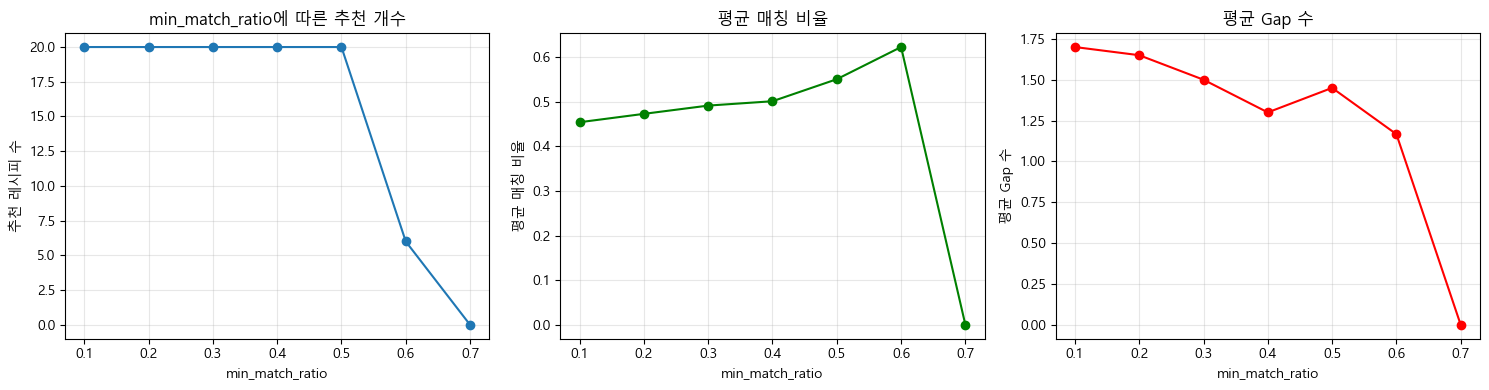

In [74]:
# 민감도 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 추천 개수
axes[0].plot(sensitivity_df['param_value'], sensitivity_df['num_recommendations'], marker='o')
axes[0].set_xlabel('min_match_ratio')
axes[0].set_ylabel('추천 레시피 수')
axes[0].set_title('min_match_ratio에 따른 추천 개수')
axes[0].grid(True, alpha=0.3)

# 평균 매칭 비율
axes[1].plot(sensitivity_df['param_value'], sensitivity_df['avg_match_ratio'], marker='o', color='green')
axes[1].set_xlabel('min_match_ratio')
axes[1].set_ylabel('평균 매칭 비율')
axes[1].set_title('평균 매칭 비율')
axes[1].grid(True, alpha=0.3)

# 평균 Gap 수
axes[2].plot(sensitivity_df['param_value'], sensitivity_df['avg_gap_count'], marker='o', color='red')
axes[2].set_xlabel('min_match_ratio')
axes[2].set_ylabel('평균 Gap 수')
axes[2].set_title('평균 Gap 수')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3.6 최적 파라미터 설정

In [75]:
# 최적 파라미터 설정
OPTIMAL_PARAMS = {
    'min_match_ratio': 0.3,    # 최소 30% 재료 매칭
    'max_gap_count': 5,        # 최대 5개까지 Gap 허용
    'popularity_weight': 0.3,  # 인기도 30% 반영
    'match_weight': 0.5,       # 매칭 비율 50% 반영
    'gap_penalty_weight': 0.2  # Gap 패널티 20%
}

model.params.update(OPTIMAL_PARAMS)

print("최적 파라미터 설정:")
for k, v in model.params.items():
    print(f"  {k}: {v}")

최적 파라미터 설정:
  min_match_ratio: 0.3
  max_gap_count: 5
  popularity_weight: 0.3
  match_weight: 0.5
  gap_penalty_weight: 0.2
  main_ingredient_bonus: 0.3
  min_ingredients: 3
  min_view_count: 500


## 3.7 모델 저장

In [76]:
# 모델 저장을 위한 데이터 패키징
model_data = {
    'recipe_ingredient_sets': recipe_ingredient_sets,
    'ingredient_to_recipes': ingredient_to_recipes,
    'recipe_metadata': recipe_metadata,
    'synonym_dict': synonym_dict,
    'params': model.params,
    'version': '1.0.0'
}

# pickle로 저장
MODEL_PATH = f'{PROCESSED_DIR}/gapfilling_model.pkl'

with open(MODEL_PATH, 'wb') as f:
    pickle.dump(model_data, f)

print(f"모델 저장 완료: {MODEL_PATH}")

# 파일 크기 확인
import os
file_size = os.path.getsize(MODEL_PATH) / (1024 * 1024)  # MB
print(f"모델 파일 크기: {file_size:.2f} MB")

모델 저장 완료: ../data/processed/gapfilling_model.pkl
모델 파일 크기: 5.91 MB


In [77]:
# 모델 로딩 테스트
with open(MODEL_PATH, 'rb') as f:
    loaded_data = pickle.load(f)

# 로딩된 데이터로 새 모델 인스턴스 생성
loaded_model = RecipeGapFillingModel(
    recipe_ingredient_sets=loaded_data['recipe_ingredient_sets'],
    ingredient_to_recipes=loaded_data['ingredient_to_recipes'],
    recipe_metadata=loaded_data['recipe_metadata'],
    synonym_dict=loaded_data['synonym_dict']
)
loaded_model.params = loaded_data['params']

# 로딩 테스트
test_results = loaded_model.recommend(['양파', '마늘', '간장'], top_k=3)
print(f"\n로딩된 모델 테스트 - 추천 레시피 {len(test_results)}개")
for rec in test_results:
    print(f"  - {rec['title']} (점수: {rec['final_score']:.3f})")

  필터링 제외: 재료부족 678개, 비요리 325개, 저조회 13,014개
GapFilling 모델 v2.0.0 초기화 완료
  - 전체 레시피 수: 23,191
  - 유효 레시피 수: 9,174
  - 재료 수: 9,147
  - 메인 재료 수: 106
  - 제외 재료 수: 39

로딩된 모델 테스트 - 추천 레시피 3개
  - 양파요리 양파장아찌 담그는법 만들기  (점수: 0.380)
  - 간단한 반찬 양파볶음 양파 요리 간장양파볶음 (점수: 0.229)
  - 마늘 장아찌 (점수: 0.229)


## 3.8 다음 단계 안내

In [78]:
print("\n" + "=" * 60)
print("3단계 완료: GapFilling 모델 구현")
print("=" * 60)
print("\n저장된 파일:")
print(f"  - 모델: {MODEL_PATH}")
print("\n모델 기능:")
print("  - recommend(): 장바구니 기반 레시피 추천")
print("  - get_gap_recommendations(): Gap 재료 추천")
print("\n다음 단계: 04_model_evaluation.ipynb에서 모델 평가 및 시각화")


3단계 완료: GapFilling 모델 구현

저장된 파일:
  - 모델: ../data/processed/gapfilling_model.pkl

모델 기능:
  - recommend(): 장바구니 기반 레시피 추천
  - get_gap_recommendations(): Gap 재료 추천

다음 단계: 04_model_evaluation.ipynb에서 모델 평가 및 시각화
